In [ ]:
from clickhouse_driver import Client
import pandas as pd
client = Client(host='clickhouse.lab.karpov.courses', port=9000, user=input('Введите свой user'),
                password=input('Введите password'), database=input('Введите БД'))

result = client.execute('SELECT * FROM user_dm_events LIMIT 10')

def get_data(query):
    """
    Вытягивает данные из clickhouse в виде Dataframe
    
    query - запрос
    """
    result, columns = client.execute(query, with_column_types=True)
    return pd.DataFrame(result, columns=[tuple[0] for tuple in columns])




import pyspark.sql.functions as F
import boto3
from botocore.exceptions import NoCredentialsError

aws_access_key = input(f'Your access_key')
aws_secret_key = input(f'Your secret_key')
s3_endpoint_url = "https://storage.yandexcloud.net"
s3_bucket = "kc-hardda-projects"

login = 'al_ivanenko'
s3 = boto3.client('s3',
                  aws_access_key_id=aws_access_key,
                  aws_secret_access_key=aws_secret_key,
                  endpoint_url=s3_endpoint_url)


try:
    s3.put_object(Bucket=s3_bucket, Key=f'{login}/')
    print(f"Folder '{login}/' created in bucket '{s3_bucket}'")
except NoCredentialsError:
    print("Invalid AWS credentials provided")
    
import os
import socket
from pyspark.sql import SparkSession

 
APACHE_MASTER_IP = socket.gethostbyname("apache-spark-master-0.apache-spark-headless.apache-spark.svc.cluster.local")
APACHE_MASTER_URL = f"spark://{APACHE_MASTER_IP}:7077"
POD_IP = os.environ["MY_POD_IP"]
SPARK_APP_NAME = f"spark-{os.environ['HOSTNAME']}"
JARS = """/nfs/env/lib/python3.8/site-packages/pyspark/jars/clickhouse-native-jdbc-shaded-2.6.5.jar, 
/nfs/env/lib/python3.8/site-packages/pyspark/jars/hadoop-aws-3.3.4.jar,
/nfs/env/lib/python3.8/site-packages/pyspark/jars/aws-java-sdk-bundle-1.12.433.jar
"""

MEM = "512m"
CORES = 1

spark = (
    SparkSession
    .builder
    .appName(SPARK_APP_NAME)
    .master(APACHE_MASTER_URL)
    .config("spark.executor.memory", MEM)
    .config("spark.jars", JARS)
    .config("spark.executor.cores", CORES)
    .config("spark.driver.host", POD_IP)
    .config("spark.hadoop.fs.s3a.access.key", aws_access_key)
    .config("spark.hadoop.fs.s3a.secret.key", aws_secret_key)
    .config("fs.s3a.endpoint", "https://storage.yandexcloud.net")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config("spark.hadoop.fs.s3a.committer.name", "directory")
    .config("spark.hadoop.fs.s3a.path.style.access", True)
    .config("spark.hadoop.fs.s3a.aws.credentials.provider", "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

Folder 'al_ivanenko/' created in bucket 'kc-hardda-projects'


26/06/19 21:40:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [6]:
get_data(f'''
    SELECT max(execution_date) 
    FROM prj_main_{login}
   
    ''')

,max(execution_date)
0,2023-01-31


26/06/19 12:31:39 ERROR TaskSchedulerImpl: Lost executor 0 on 10.112.129.173: Remote RPC client disassociated. Likely due to containers exceeding thresholds, or network issues. Check driver logs for WARN messages.


In [31]:
client.execute(f'''
    DROP TABLE prj_agg_2_mv_{login}
    ''')

[]

In [32]:
client.execute(f'''
    CREATE TABLE IF NOT EXISTS prj_agg_2_{login} (
    user_type LowCardinality(String)
    , auto_brand LowCardinality(String)
    , advert_id UInt64
    , min_date AggregateFunction(min, Date)
    , max_date AggregateFunction(max, Date) 
    
    )
    ENGINE = AggregatingMergeTree()
    ORDER BY(user_type, auto_brand, advert_id)
    ''')

client.execute(f'''
    CREATE MATERIALIZED VIEW IF NOT EXISTS prj_agg_2_mv_{login}
    TO prj_agg_2_{login}
    AS
        SELECT user_type
            , auto_brand
            , advert_id
            , minState(execution_date) as min_date
            , maxState(execution_date) as max_date
        FROM prj_main_{login}
    
    GROUP BY user_type, auto_brand, advert_id
    ''')


[]

In [33]:
client.execute(f'''
    insert into prj_main_{login}
    select * from prj_s3_ext_{login}
    ''')

[]

In [119]:
kk = get_data(f'''
    with tt as (
        SELECT advert_id
            , dateDiff('day', minMerge(min_date), maxMerge(max_date)) as lifetime_adv 
        FROM prj_agg_2_{login}
        GROUP BY advert_id
    )
    
    SELECT lifetime_adv, count() as cnt from tt
    
    GROUP BY lifetime_adv
    ORDER BY cnt desc

    ''')
kk

,lifetime_adv,cnt
0,7,248199
1,6,107077
2,1,63611
3,2,49109
4,5,47439
...,...,...
360,312,14
361,311,14
362,332,13
363,316,12


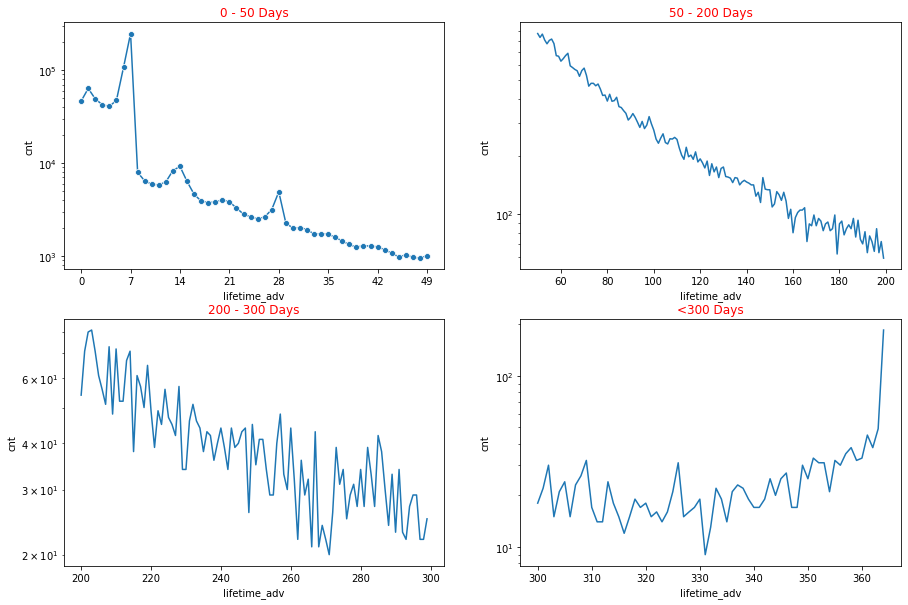

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.DataFrame(kk[kk['lifetime_adv'] < 50] , columns = ['lifetime_adv','cnt'])
df2 = pd.DataFrame(kk[(kk['lifetime_adv'] >= 50) & (kk['lifetime_adv'] < 200)] , columns = ['lifetime_adv','cnt'])
df3 = pd.DataFrame(kk[(kk['lifetime_adv'] >= 200) & (kk['lifetime_adv'] < 300)] , columns = ['lifetime_adv','cnt'])
df4 = pd.DataFrame(kk[kk['lifetime_adv'] >= 300] , columns = ['lifetime_adv','cnt'])

fig, axes = plt.subplots(2,2, figsize=(15,10) )

sns.lineplot(data=df1, x = 'lifetime_adv', y='cnt', ax=axes[0][0], marker = 'o')
sns.lineplot(data=df2, x = 'lifetime_adv', y='cnt', ax=axes[0][1])
sns.lineplot(data=df3, x = 'lifetime_adv', y='cnt', ax=axes[1][0])
sns.lineplot(data=df4, x = 'lifetime_adv', y='cnt', ax=axes[1][1])


axes[0][0].set_yscale('log')
axes[0][1].set_yscale('log')
axes[1][0].set_yscale('log')
axes[1][1].set_yscale('log')


axes[0][0].set_title('0 - 50 Days', c='r')
axes[0][1].set_title('50 - 200 Days', c='r')
axes[1][0].set_title('200 - 300 Days', c='r')
axes[1][1].set_title('<300 Days', c='r')

axes[0][0].set_xticks(range(0,56,7))


In [139]:
# Чаще всего встречается значение lifetime = 7. + 

# После 7 дней значений резко становится меньше. + 

# Есть всплески на 14 и 28 днях (и небольшой в районе 20-21). +

# Большой всплеск на 30 днях. - 

# После 200 дней количество значений снова становится больше (и продолжает расти до 250 дней). -

# Есть вслеск в самом конце, но не очень большой. + 

# Объявлений с lifetime более полугода — меньше процента. + 
round(kk[kk['lifetime_adv'] > 180]['cnt'].sum() / kk['cnt'].sum(),3)

0.009

In [132]:
kk.count()[1]

365

In [19]:
get_data(f'''
    with tt as (SELECT advert_id, auto_brand, dateDiff('day', minMerge(min_date), maxMerge(max_date) ) as diff_date FROM prj_agg_2_{login}
    GROUP BY advert_id, auto_brand)
    
    SELECT auto_brand, round(AVG(diff_date),2) as avg_date
        , round(median(diff_date),2) as median_date
        , count() as cnt
    FROM tt 
    GROUP BY auto_brand 
    HAVING cnt > 10
    ORDER BY median_date DESC
    ''')

,auto_brand,avg_date,median_date,cnt
0,BAIC,89.08,31.5,12
1,Bentley,37.08,14.0,13
2,Mini,32.15,14.0,27
3,Derways,30.64,10.0,11
4,Tesla,41.85,9.0,13
...,...,...,...,...
84,Proton,5.64,6.0,14
85,ВАЗ (Lada),9.41,6.0,233658
86,Haima,10.23,5.0,87
87,Smart,23.53,2.0,38


Считаем усечённое среднее

In [66]:
get_data(f'''
    with adverts as (
        SELECT advert_id, auto_brand
            , round(dateDiff('day', minMerge(min_date), maxMerge(max_date)),1) as lifetime
        FROM prj_agg_2_{login}
        GROUP BY advert_id, auto_brand
        )
    , quantiles_per_group as (
    SELECT auto_brand
        , quantile(0.25)(lifetime) as q25_date
        , quantile(0.75)(lifetime) as q75_date
    FROM adverts
    GROUP BY  auto_brand
    )
    
    SELECT auto_brand
        , count() as cnt
        , round(avg(lifetime),2) as avg_date
        , median(lifetime) as median_date
        , coalesce(avgIfOrNull(lifetime, lifetime >= q25_date AND lifetime <= q75_date), median(lifetime))  as tmean_lifetime
        
    FROM adverts
    INNER JOIN quantiles_per_group
    USING(auto_brand)
    GROUP BY auto_brand
    --HAVING cnt >= 10
    ORDER BY tmean_lifetime DESC
    ''')

,auto_brand,cnt,avg_date,median_date,tmean_lifetime
0,Dacia,1,118.00,118.0,118.000000
1,Puch,4,134.25,71.0,71.000000
2,BAIC,12,89.08,31.5,55.666667
3,Hongqi,1,43.00,43.0,43.000000
4,Maserati,3,32.33,29.0,29.000000
...,...,...,...,...,...
113,Gonow,1,2.00,2.0,2.000000
114,Hawtai,1,1.00,1.0,1.000000
115,Bajaj,1,0.00,0.0,0.000000
116,Bugatti,4,0.25,0.0,0.000000


In [80]:
get_data(f'''
    with adverts as (
        SELECT advert_id, auto_brand,  round(dateDiff('day', minMerge(min_date), maxMerge(max_date)),1) as lifetime
        FROM prj_agg_2_{login}
        GROUP BY advert_id, auto_brand
        )
    , quantiles_per_group as (
    SELECT auto_brand
        , quantileExact(0.25)(lifetime) as q25_date
        , quantileExact(0.75)(lifetime) as q75_date
        
    FROM adverts
    GROUP BY  auto_brand
    )
    
    SELECT auto_brand, count() as cnt
        , round(avg(lifetime),2) as avg_date
        , median(lifetime) as median_date
        , coalesce(avgIfOrNull(lifetime, lifetime >= q25_date AND lifetime <= q75_date), median(lifetime))  as tmean_lifetime
        
    FROM adverts
    INNER JOIN quantiles_per_group
    USING(auto_brand)
    WHERE auto_brand IN ('Bentley', 'Mini', 'BAIC', 'Haima', 'Alfa Romeo', 'Scion', 'Lancia', 'Tianye', 'Smart', 'Ravon')
    GROUP BY auto_brand
    --HAVING cnt >= 10
    ORDER BY tmean_lifetime 
    ''')

,auto_brand,cnt,avg_date,median_date,tmean_lifetime
0,Alfa Romeo,274,4.08,2.0,2.581731
1,Smart,38,23.53,2.0,3.034483
2,Tianye,24,16.67,6.0,4.923077
3,Haima,87,10.23,5.0,5.018868
4,Ravon,1660,14.17,6.0,5.575055
5,Scion,10,23.50,10.0,15.428571
6,Bentley,13,37.08,14.0,17.125000
7,Mini,27,32.15,14.0,18.764706
8,Lancia,10,36.60,17.0,18.833333
9,BAIC,12,89.08,31.5,77.428571
